### Lasso Regression Theory

Lasso Regression is a regularization technique for linear regression that performs variable selection by adding an L1 penalty to the ordinary least squares (OLS) objective. It is useful when you want a sparse model with some coefficients exactly zero.

#### Objective Function
The Lasso estimator minimizes the penalized residual sum of squares:

$$
\min_{\beta} \left( \sum_{i=1}^{n} (y_i - X_i \beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right)
$$

where:
- \( y_i \) is the response variable for the \( i \)-th observation,
- \( X_i \) is the vector of predictors for the \( i \)-th observation,
- \( \beta \) is the vector of coefficients,
- \( \lambda \geq 0 \) is the regularization parameter,
- \( n \) is the number of observations,
- \( p \) is the number of predictors.

In matrix form:

$$
\min_{\beta} \left( (y - X\beta)^T (y - X\beta) + \lambda \|\beta\|_1 \right)
$$

#### Solution Characteristics
Unlike Ridge, Lasso does not have a simple closed-form solution. The estimator is typically found using convex optimization algorithms such as coordinate descent or least-angle regression (LARS).

#### Key Properties
- **Sparsity**: Lasso can set some coefficients exactly to zero, yielding simpler models and feature selection.
- **Bias-Variance Tradeoff**: It introduces bias to reduce variance, which can improve prediction on new data.
- **Variable Selection**: Useful when many predictors may be irrelevant.
- **Hyperparameter Tuning**: \( \lambda \) is usually chosen by cross-validation to balance fit and sparsity.

#### Assumptions and Limitations
- Assumes a linear relationship between predictors and response.
- Predictors should be standardized for meaningful penalization.
- May select only one variable among a group of correlated predictors and shrink others to zero.
- Not ideal when all predictors are relevant but with small effects; in that case, Ridge may be preferable.

Best alpha: 0.00080
Coefficienti non zero:
Latitude     -0.888039
Longitude    -0.860441
MedInc        0.850206
AveBedrms     0.328723
AveRooms     -0.283936
HouseAge      0.123187
AveOccup     -0.040079
Population   -0.001312
dtype: float64
RMSE: 0.7448, R2: 0.5766


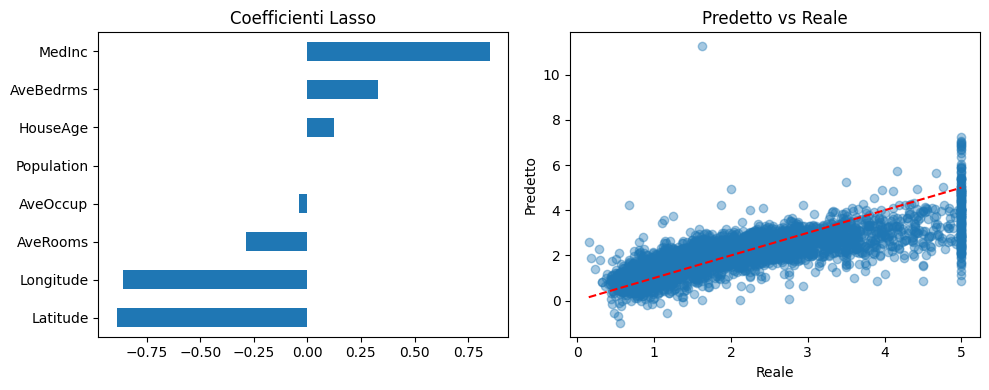

In [2]:
# Lasso su dati reali (California Housing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn import metrics

# carica dati
data = fetch_california_housing(as_frame=True)
X = data.frame.drop(columns=[data.target_names[0]])
y = data.frame[data.target_names[0]]

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardizzazione (importante per Lasso)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Lasso con cross-validation per scegliere alpha
lasso_cv = LassoCV(cv=5, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_s, y_train)

# risultati
alpha_best = lasso_cv.alpha_
coefs = pd.Series(lasso_cv.coef_, index=X.columns)
nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False)

print(f"Best alpha: {alpha_best:.5f}")
print("Coefficienti non zero:")
print(nonzero)

# valutazione
y_pred = lasso_cv.predict(X_test_s)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}, R2: {r2:.4f}")

# plot coefficienti e predetti vs reali
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
coefs.sort_values().plot(kind='barh')
plt.title('Coefficienti Lasso')
plt.tight_layout()

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Reale')
plt.ylabel('Predetto')
plt.title('Predetto vs Reale')
plt.tight_layout()
plt.show()